# Phase 2 Handoff Summary

This notebook is a single Phase 2 entry point for report integration.

It combines the current materials for:

1. Problem Definition & Data Preparation
2. Model Implementation & Training
3. Model Evaluation & Comparison
4. Model Interpretation & Business Insights

It is intended to help teammates quickly review the current status, inspect the most important result tables, and reuse the findings for the final PDF write-up.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Markdown, display, Image

REPO_NAME = 'Team22_IT5006_Predictive_Policing_AY2526Sem2'

def looks_like_project_root(path: Path) -> bool:
    return (
        (path / 'artifacts' / 'metrics').exists()
        and (path / 'docs').exists()
        and (path / 'notebooks').exists()
    )

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]

    home = Path.home()
    candidates.extend([
        home / 'Documents' / 'Playground' / REPO_NAME,
        home / 'Documents' / 'GitHub' / REPO_NAME,
        home / REPO_NAME,
    ])

    for base in [home / 'Documents' / 'Playground', home / 'Documents' / 'GitHub']:
        if base.exists():
            candidates.extend(base.glob(f'**/{REPO_NAME}'))

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if looks_like_project_root(candidate):
            return candidate

    raise FileNotFoundError(
        'Could not find the project root automatically. Please place this notebook inside the project repo, or set PROJECT_ROOT manually.'
    )

PROJECT_ROOT = find_project_root()
DOCS_DIR = PROJECT_ROOT / 'docs'
METRICS_DIR = PROJECT_ROOT / 'artifacts' / 'metrics'
FEATURE_DIR = METRICS_DIR / 'feature_importance'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

print('Project root:', PROJECT_ROOT)
print('Docs dir:', DOCS_DIR)
print('Metrics dir:', METRICS_DIR)

Project root: /Users/jiahaojing/Documents/Playground/Team22_IT5006_Predictive_Policing_AY2526Sem2
Docs dir: /Users/jiahaojing/Documents/Playground/Team22_IT5006_Predictive_Policing_AY2526Sem2/docs
Metrics dir: /Users/jiahaojing/Documents/Playground/Team22_IT5006_Predictive_Policing_AY2526Sem2/artifacts/metrics


## 1. Problem Definition & Data Preparation

### Problem framing

The current Phase 2 task is framed as a **binary occurrence-prediction problem**:

- input: a location-time context
- output: whether a crime occurrence is predicted (`target = 1`) or not (`target = 0`)

This is not crime-type classification. The goal is to support higher-risk time-location awareness.

### Preprocessing and leakage control

The pipeline intentionally uses only information that could plausibly be available before an event. Post-incident fields such as `Primary Type`, `Description`, `IUCR`, `Arrest`, and `Domestic` were excluded to avoid target leakage.

### Feature engineering

The final feature space combines:

- temporal features: hour, weekday, month, day-of-year, cyclic encodings
- behavioral indicators: weekend, night-time, rush-hour
- spatial features: district, ward, beat, community area, coordinates, grid cell
- historical features: prior crime counts over 7d, 14d, 30d, and 90d windows

The full Part 1 and Part 2 write-up is available in:

- `docs/phase2_part1_part2_draft.md`
- `docs/phase2_methodology.md`

In [2]:
data_summary_path = METRICS_DIR / 'phase2_data_summary.json'
with open(data_summary_path, 'r', encoding='utf-8') as f:
    data_summary = json.load(f)

summary_df = pd.DataFrame([
    {'item': 'positive_rows', 'value': data_summary.get('positive_rows')},
    {'item': 'negative_rows', 'value': data_summary.get('negative_rows')},
    {'item': 'total_rows', 'value': data_summary.get('total_rows')},
    {'item': 'positive_rate', 'value': data_summary.get('positive_rate')},
    {'item': 'feature_count', 'value': data_summary.get('feature_count')},
    {'item': 'train_rows', 'value': data_summary.get('train_rows')},
    {'item': 'val_rows', 'value': data_summary.get('val_rows')},
    {'item': 'test_rows', 'value': data_summary.get('test_rows')},
])

display(Markdown('### Current dataset summary'))
display(summary_df)

### Current dataset summary

,item,value
0,positive_rows,60000.0
1,negative_rows,60000.0
2,total_rows,NaN
3,positive_rate,NaN
4,feature_count,37.0
5,train_rows,83820.0
6,val_rows,17999.0
7,test_rows,17999.0


## 2. Model Implementation & Training

Three tabular models are currently implemented and saved:

1. Logistic Regression
2. Random Forest
3. HistGradientBoosting

These models were chosen to cover a linear baseline and two nonlinear ensemble baselines. The current reproducible training workflow is implemented in `src/scripts/train.py`, and the preprocessing logic is in `src/data/processor.py`.

Saved model files are under:

- `artifacts/models/logistic_regression.pkl`
- `artifacts/models/random_forest.pkl`
- `artifacts/models/hist_gradient_boosting.pkl`

In [3]:
metrics_df = pd.read_csv(METRICS_DIR / 'phase2_model_metrics.csv')
trials_df = pd.read_csv(METRICS_DIR / 'phase2_model_trials.csv')

display(Markdown('### Main model metrics'))
display(metrics_df)

display(Markdown('### Hyperparameter trial summary'))
display(trials_df)

### Main model metrics

,model,split,params,accuracy,precision,recall,f1,auroc,auprc
0,hist_gradient_boosting,test,"{""l2_regularization"": 0.1, ""learning_rate"": 0....",0.566476,0.550091,0.736100,0.629645,0.591214,0.572780
1,random_forest,test,"{""max_depth"": 16, ""max_features"": ""sqrt"", ""max...",0.562587,0.550749,0.685274,0.610691,0.583578,0.567669
2,logistic_regression,test,"{""C"": 0.5, ""max_iter"": 400}",0.564865,0.563082,0.583953,0.573328,0.576677,0.549932
3,hist_gradient_boosting,val,"{""l2_regularization"": 0.1, ""learning_rate"": 0....",0.565254,0.543562,0.756654,0.632646,0.588691,0.562939
4,random_forest,val,"{""max_depth"": 16, ""max_features"": ""sqrt"", ""max...",0.561476,0.543583,0.708703,0.615257,0.585636,0.559601
5,logistic_regression,val,"{""C"": 0.5, ""max_iter"": 400}",0.563476,0.555804,0.586075,0.570538,0.579190,0.548987


### Hyperparameter trial summary

,model,trial,split,params,accuracy,precision,recall,f1,auroc,auprc
0,logistic_regression,1,val,"{""C"": 0.5, ""max_iter"": 400}",0.563476,0.555804,0.586075,0.570538,0.579190,0.548987
1,logistic_regression,2,val,"{""C"": 1.0, ""max_iter"": 600}",0.563365,0.555686,0.586075,0.570476,0.579074,0.548686
2,random_forest,1,val,"{""max_depth"": 16, ""max_features"": ""sqrt"", ""max...",0.561476,0.543583,0.708703,0.615257,0.585636,0.559601
3,random_forest,2,val,"{""max_depth"": 20, ""max_features"": ""sqrt"", ""max...",0.557975,0.543211,0.669848,0.599920,0.580579,0.554918
4,hist_gradient_boosting,1,val,"{""l2_regularization"": 0.0, ""learning_rate"": 0....",0.564142,0.543336,0.746210,0.628815,0.587884,0.561455
5,hist_gradient_boosting,2,val,"{""l2_regularization"": 0.1, ""learning_rate"": 0....",0.565254,0.543562,0.756654,0.632646,0.588691,0.562939


## 3. Model Evaluation & Comparison

The current evaluation conclusion is:

- `HistGradientBoosting` is the strongest overall model
- `Random Forest` is the second-best model
- `Logistic Regression` is a weaker but interpretable baseline

Important interpretation note:

- record-level classification performance is moderate and usable for comparison
- temporal alignment is much stronger than district-level spatial alignment
- district-level spatial ranking remains weak in the current setup

The integrated Part 3 and Part 4 report draft is available in:

- `docs/phase2_part3_part4_draft.md`

In [4]:
display(Markdown('### Best model by test AUROC'))
best_test = metrics_df[metrics_df['split'] == 'test'].sort_values('auroc', ascending=False)
display(best_test[['model', 'accuracy', 'precision', 'recall', 'f1', 'auroc', 'auprc']])

### Best model by test AUROC

,model,accuracy,precision,recall,f1,auroc,auprc
0,hist_gradient_boosting,0.566476,0.550091,0.736100,0.629645,0.591214,0.572780
1,random_forest,0.562587,0.550749,0.685274,0.610691,0.583578,0.567669
2,logistic_regression,0.564865,0.563082,0.583953,0.573328,0.576677,0.549932


### Spatial and temporal evaluation summary

Current cleaned-up interpretation:

- district-level spatial alignment is weak overall
- even if some plots show partial trend similarity, that should only be treated as qualitative context
- hourly temporal alignment is strong
- day-of-week temporal alignment is much less stable

This wording is intentionally stricter than the earlier rough draft so the final PDF keeps a consistent conclusion.

## 4. Feature Importance, Interpretation, and Business Insights

A stronger feature-importance analysis has now been added for Part 4. Different models use different importance methods:

- Logistic Regression: absolute coefficients
- Random Forest: impurity-based feature importance
- HistGradientBoosting: permutation importance on the held-out test split

The main addendum is in:

- `docs/phase2_part4_feature_importance_addendum.md`

In [5]:
with open(FEATURE_DIR / 'feature_importance_summary.json', 'r', encoding='utf-8') as f:
    fi_summary = json.load(f)

display(Markdown(f"### Best model for interpretation: `{fi_summary['best_model']}`"))
display(pd.DataFrame(fi_summary['top_features']))

display(Markdown('### Feature group contribution shares'))
display(pd.DataFrame(fi_summary['feature_groups']))

### Best model for interpretation: `hist_gradient_boosting`

,feature,importance,importance_std
0,hour_sin,0.049623,0.000098
1,hour,0.030686,0.000940
2,day_of_week,0.001682,0.000336
3,dow_sin,0.001245,0.000429
4,X Coordinate,-0.000979,0.000312
5,crimes_last_30d,0.000803,0.000000
6,Y Coordinate,-0.000638,0.000771
7,Community Area,-0.000496,0.000355
8,Beat,0.000492,0.002636
9,Latitude,-0.000448,0.000645


### Feature group contribution shares

,feature_group,importance_abs,importance_share
0,temporal,0.084198,0.942662
1,spatial,0.003648,0.040842
2,historical,0.001211,0.013564
3,missing_indicator,0.000262,0.002932


### Top-15 feature-importance figures

#### logistic_regression_feature_importance_top15.png

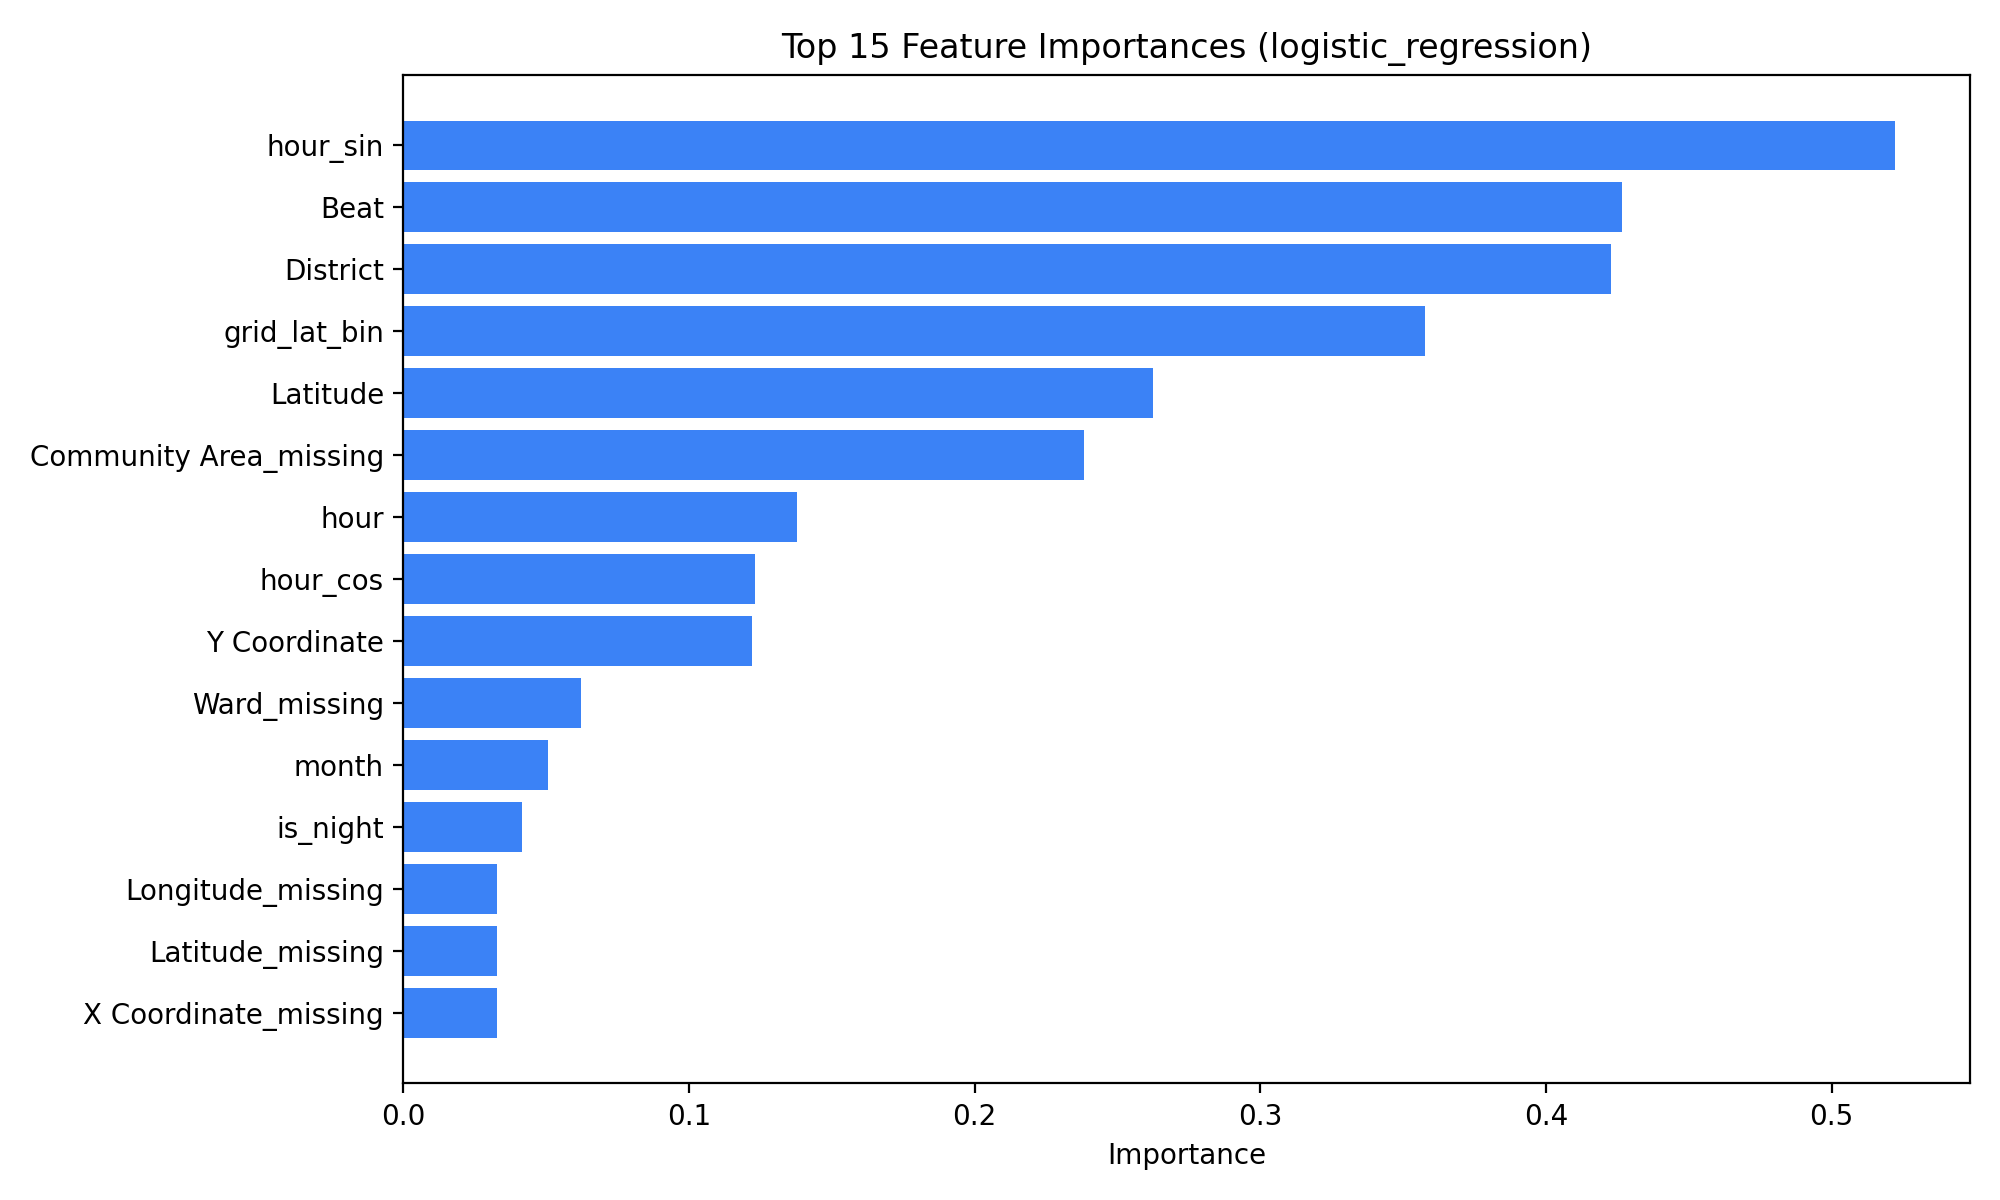

#### random_forest_feature_importance_top15.png

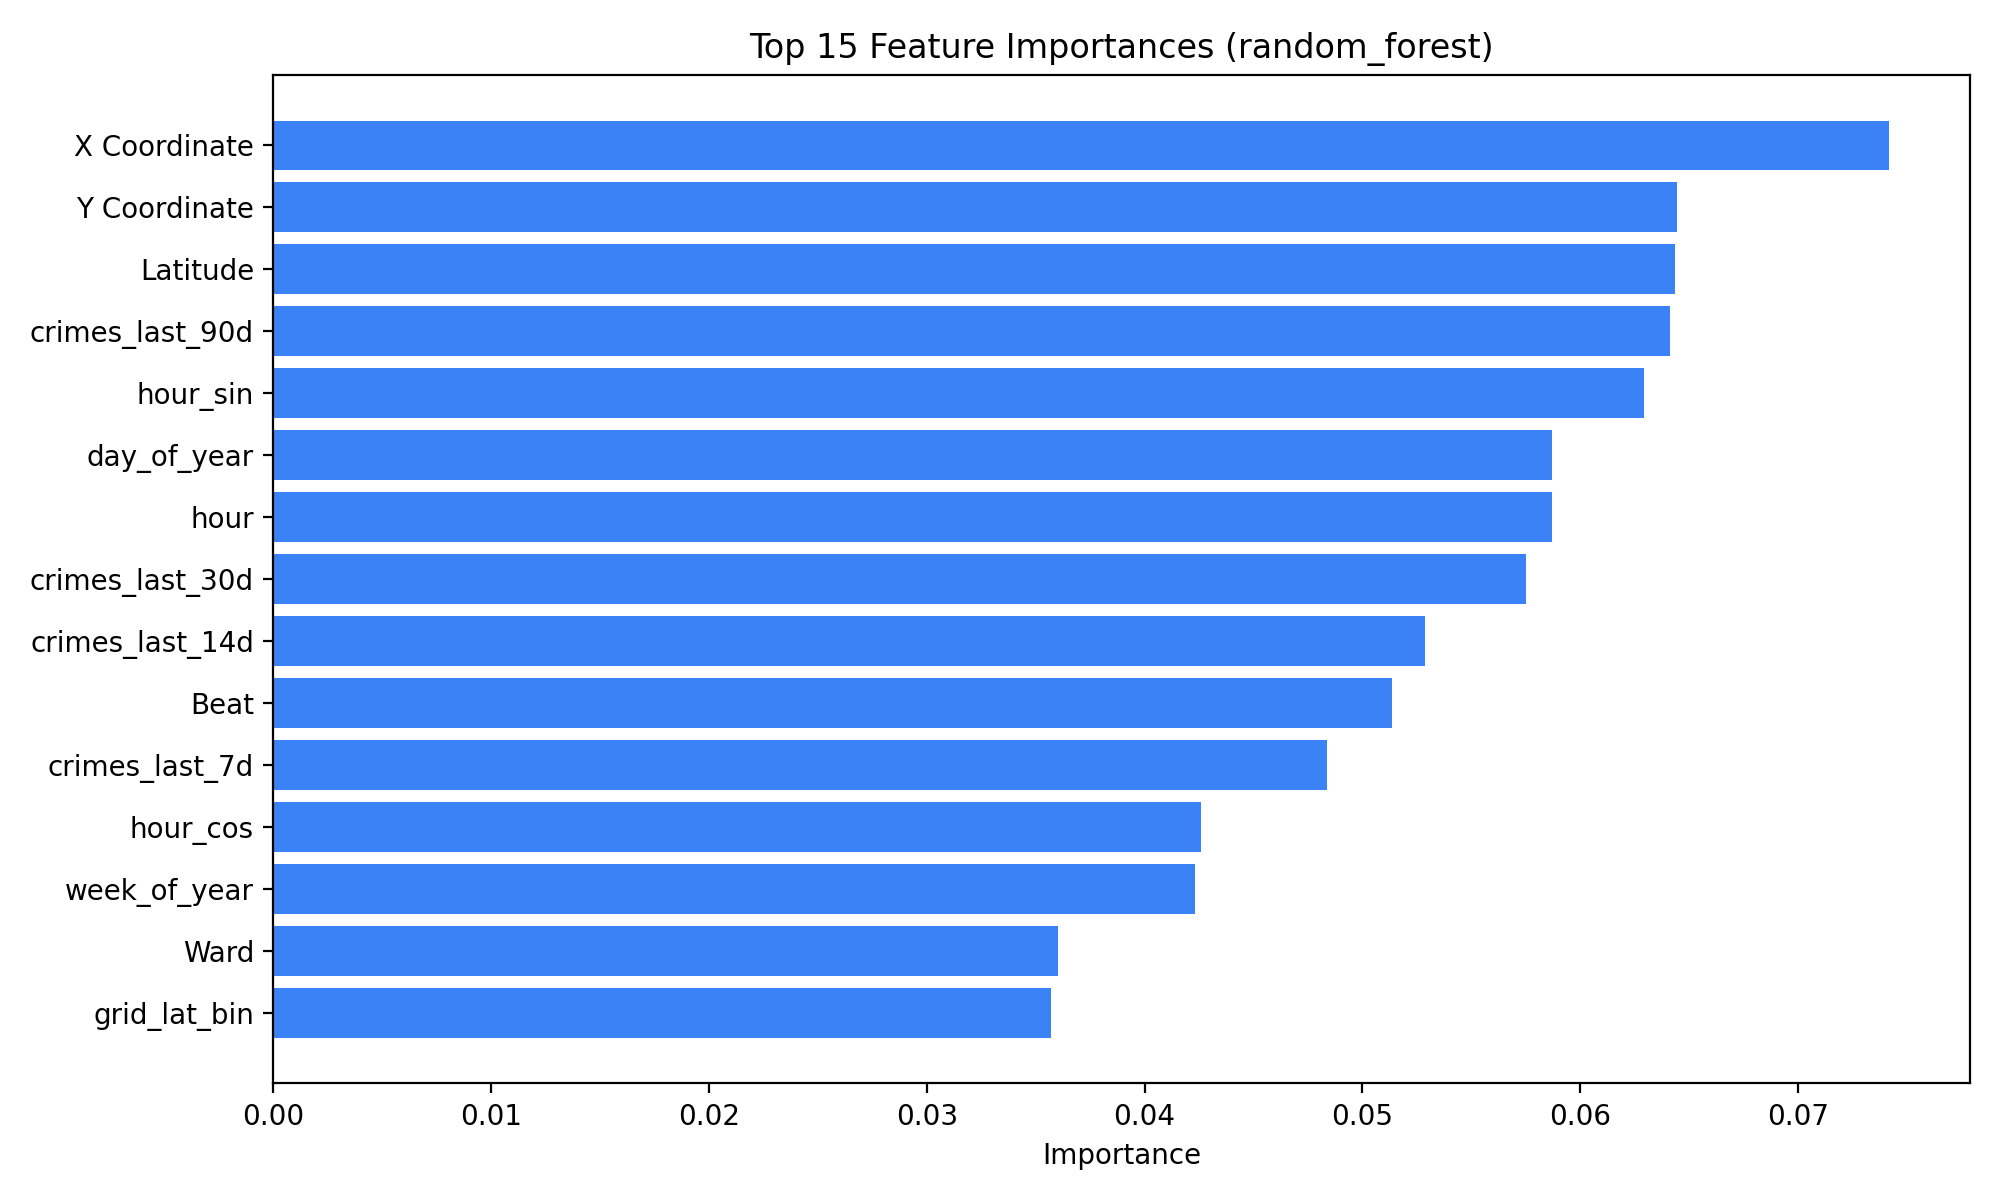

#### hist_gradient_boosting_feature_importance_top15.png

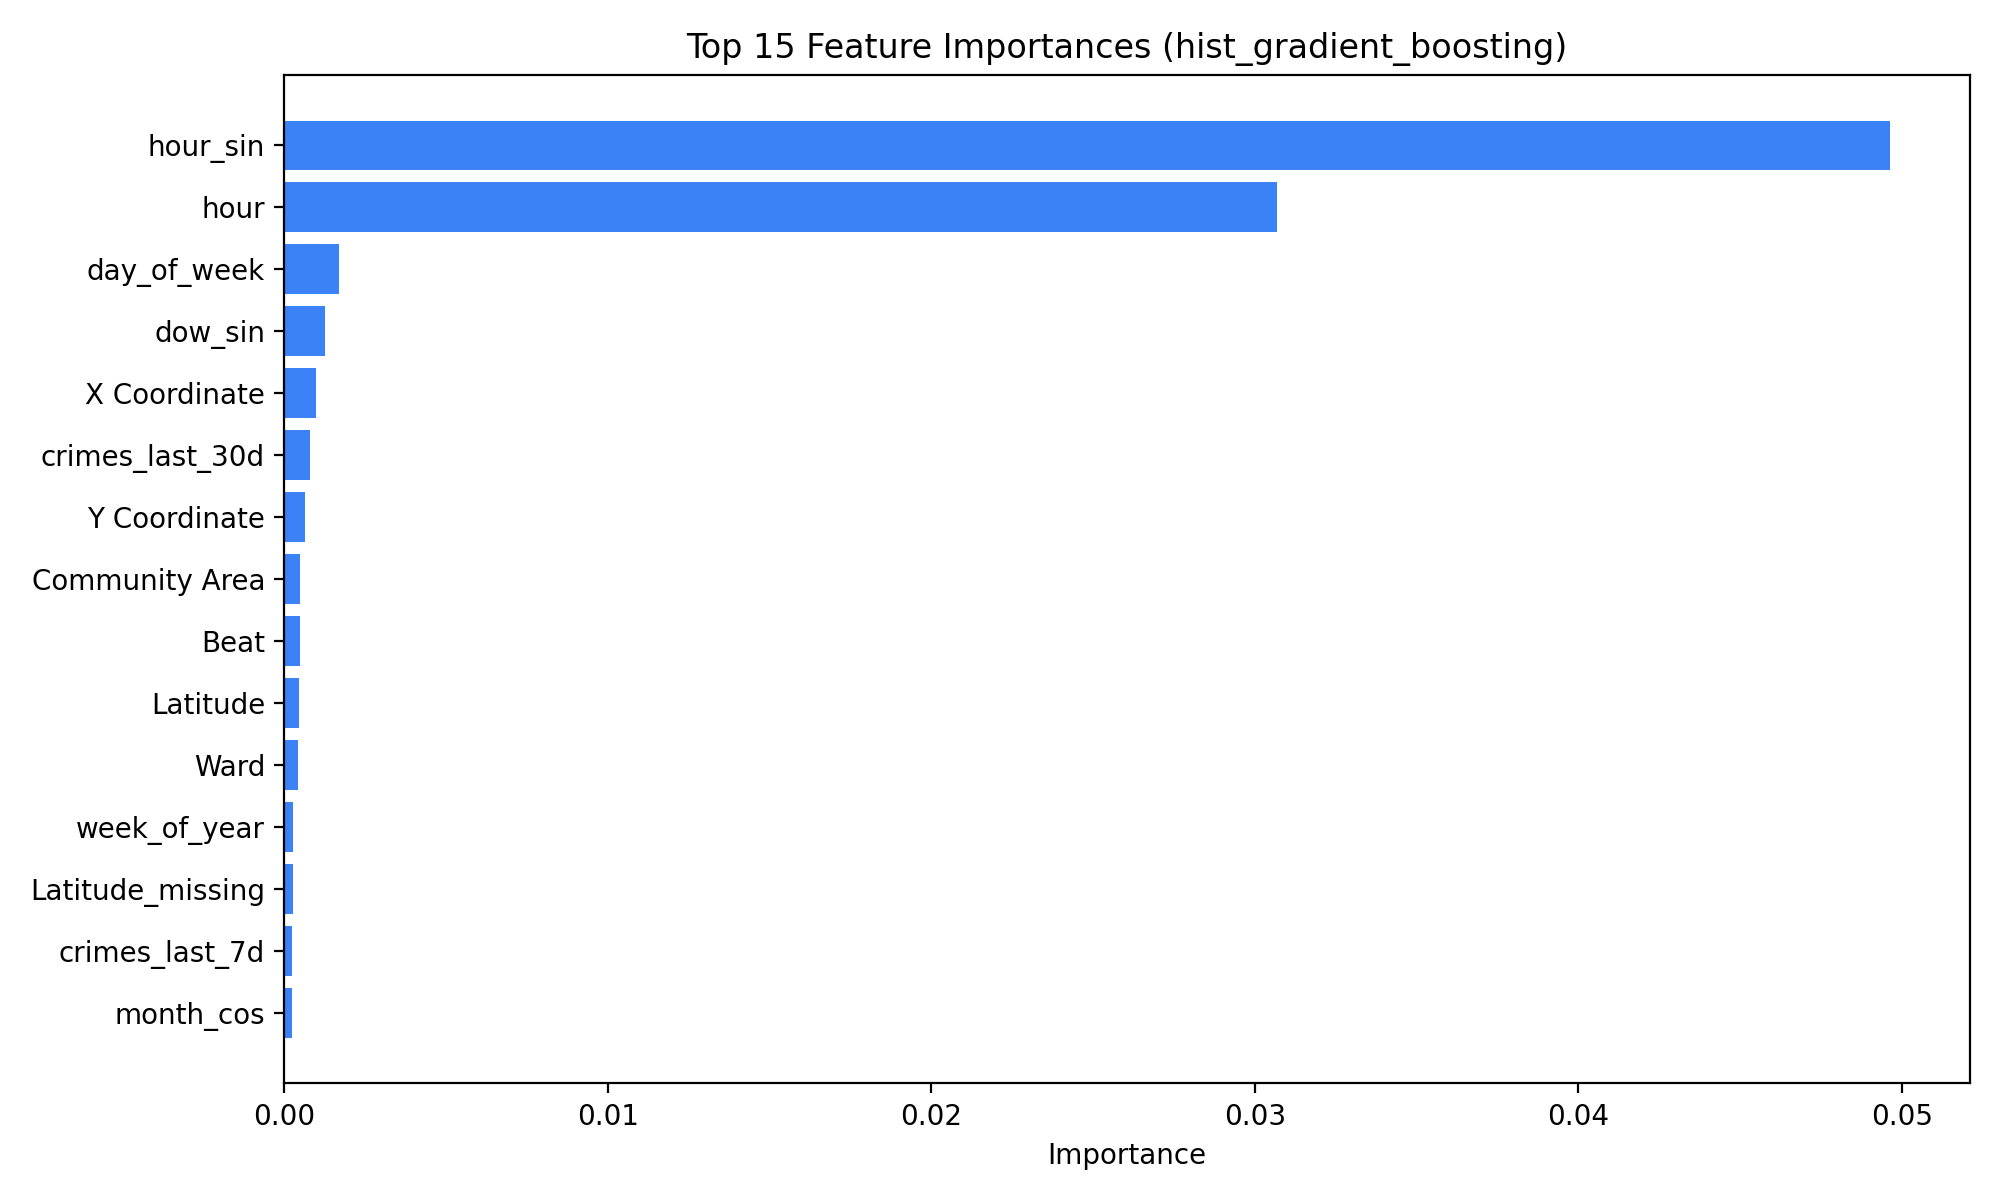

In [6]:
display(Markdown('### Top-15 feature-importance figures'))
for image_name in [
    'logistic_regression_feature_importance_top15.png',
    'random_forest_feature_importance_top15.png',
    'hist_gradient_boosting_feature_importance_top15.png',
]:
    image_path = FEATURE_DIR / image_name
    if image_path.exists():
        display(Markdown(f'#### {image_name}'))
        display(Image(filename=str(image_path)))

### Interpretation takeaway

The current evidence suggests that short-term temporal patterns are the strongest signal in this benchmark. Spatial context still matters as supporting information, while historical crime-count features contribute but are less dominant than the strongest temporal features for the best model.

Business interpretation should remain careful:

- the model is best framed as a decision-support tool
- it is more useful for timing-sensitive risk awareness than for strong district ranking claims
- the current benchmark is sampled and should not be presented as a production-ready system

## 5. Useful files for final report integration

If the final PDF is being assembled now, the most useful source files are:

- `docs/phase2_part1_part2_draft.md`
- `docs/phase2_part3_part4_draft.md`
- `docs/phase2_part4_feature_importance_addendum.md`
- `artifacts/metrics/phase2_model_metrics.csv`
- `artifacts/metrics/phase2_model_trials.csv`
- `artifacts/metrics/feature_importance/`
- `artifacts/metrics/predictions/`

This notebook is meant to serve as the quickest handoff view, while the files above remain the canonical sources.